In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA = PROJECT_DIR/"processed"/"cleaned_dataset.csv"

df = pd.read_csv(DATA)

print(df.shape)

df.head()

(23424, 48)


,Week,Measurement_Site,Latitude,Longitude,Source_File,Vehicle_Category,Time,von Unten nach Oben,von Links nach Oben,von Links nach Unten,von Oben nach Unten,Fahrtrichtung Süd-West,Fahrtrichtung Nord-Ost,Fahrtrichtung Nord-West,Fahrtrichtung Süd-Ost,Fahrtrichtung Nord-Ost.1,Fahrtrichtung Süd-West.1,von Rechts nach Unten,von Rechts nach Oben,Von Links nach Oben,Von Links nach Unten,Von Oben nach Unten,Fahrtrichtung Süd,Fahrtrichtung Nord,Fahrtrichtung West,Fahrtrichtung Ost,Leicht-rechts in Links,Rechts in Oben,Geradeaus in Links,Rechts in Oben.1,Falschfahrer,Falschfahrer.1,Falschfahrer.2,Geradeaus in Unten,Geradeaus in Oben,Fahrtrichtung Nord.1,Fahrtrichtung Süd.1,von Rechts Links nach Unten,von Links Geradeaus in Rechts,von Oben Links in Rechts,von Oben Geradeaus in Unten,von Unten Geradeaus in Oben,nach Unten,Total_Traffic,Hour,Minute,Peak_Period,Time_Interval
0,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,Off Peak,00:00
1,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,15,Off Peak,00:15
2,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,30,Off Peak,00:30
3,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:45:00,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0,45,Off Peak,00:45
4,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 01:00:00,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1,0,Off Peak,01:00


In [3]:
print("="*60)

print("Survey Weeks")

print("="*60)

print(df["Week"].unique())

Survey Weeks
<ArrowStringArray>
['DZwEI 08.10-13.10', 'DZwEI 09.09-15.09', 'DZwEI 14.10-22.10',
 'DZwEI 16.09-23.09', 'DZwEI 24.09-29.09', 'DZwEI 30.09-07.10']
Length: 6, dtype: str


In [4]:
weekly_avg = (

    df

    .groupby("Week")

    ["Total_Traffic"]

    .mean()

    .sort_values(
        ascending=False
    )

)

weekly_avg

Week
DZwEI 16.09-23.09    166.916406
DZwEI 09.09-15.09     98.383073
DZwEI 24.09-29.09     75.917215
DZwEI 30.09-07.10     74.171327
DZwEI 08.10-13.10     48.961648
DZwEI 14.10-22.10     46.003551
Name: Total_Traffic, dtype: float64

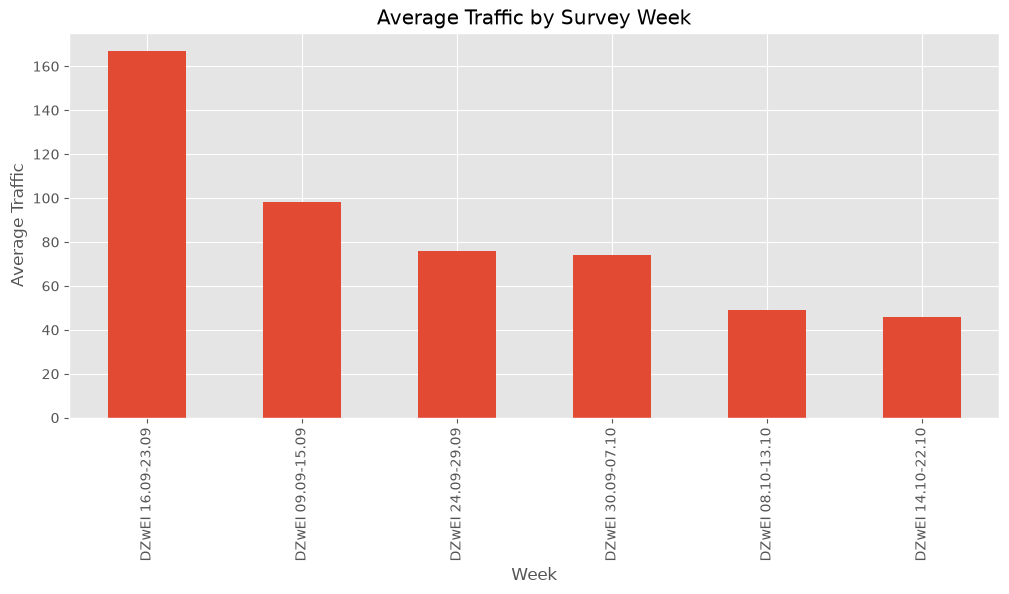

In [5]:
plt.figure(figsize=(12,5))

weekly_avg.plot(kind="bar")

plt.ylabel("Average Traffic")

plt.title("Average Traffic by Survey Week")

plt.show()

In [6]:
heatmap = pd.pivot_table(

    df,

    values="Total_Traffic",

    index="Week",

    columns="Hour",

    aggfunc="mean"

)

heatmap

Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Week,,,,,,,,,,,,,,,,,,,,,,,,
DZwEI 08.10-13.10,8.045455,6.085227,4.346591,4.721591,4.960227,12.562500,29.914773,60.136364,81.715909,77.454545,79.022727,76.977273,76.261364,75.392045,76.602273,80.812500,83.352273,79.210227,75.835227,59.693182,43.244318,35.744318,25.107955,17.880682
DZwEI 09.09-15.09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,78.443750,151.693750,167.531250,165.400000,176.037500,192.743750,206.968750,220.162500,222.450000,219.825000,172.837500,133.850000,107.306250,89.468750,56.475000
DZwEI 14.10-22.10,8.079545,5.676136,3.051136,3.732955,4.346591,12.801136,29.659091,47.931818,60.801136,60.954545,68.829545,78.000000,80.744318,78.306818,77.011364,80.113636,80.164773,79.346591,74.812500,57.170455,42.187500,31.875000,22.789773,15.698864
DZwEI 16.09-23.09,35.700000,20.456250,16.162500,16.125000,18.093750,53.718750,127.462500,223.162500,262.275000,232.818750,207.112500,218.643750,232.406250,237.412500,256.012500,282.693750,291.225000,300.731250,275.981250,215.606250,170.737500,129.225000,111.900000,70.331250
DZwEI 24.09-29.09,16.789474,10.453947,8.111842,6.184211,8.000000,20.855263,46.842105,81.664474,98.618421,97.026316,98.078947,102.835526,108.131579,116.065789,119.000000,135.967105,135.138158,141.131579,138.598684,106.013158,79.118421,60.552632,54.901316,31.934211
DZwEI 30.09-07.10,18.184211,11.210526,7.888158,6.322368,7.177632,19.835526,48.592105,91.105263,104.723684,97.151316,97.348684,101.309211,105.835526,113.111842,117.236842,122.631579,129.875000,135.177632,126.092105,96.723684,78.815789,59.789474,52.993421,30.980263


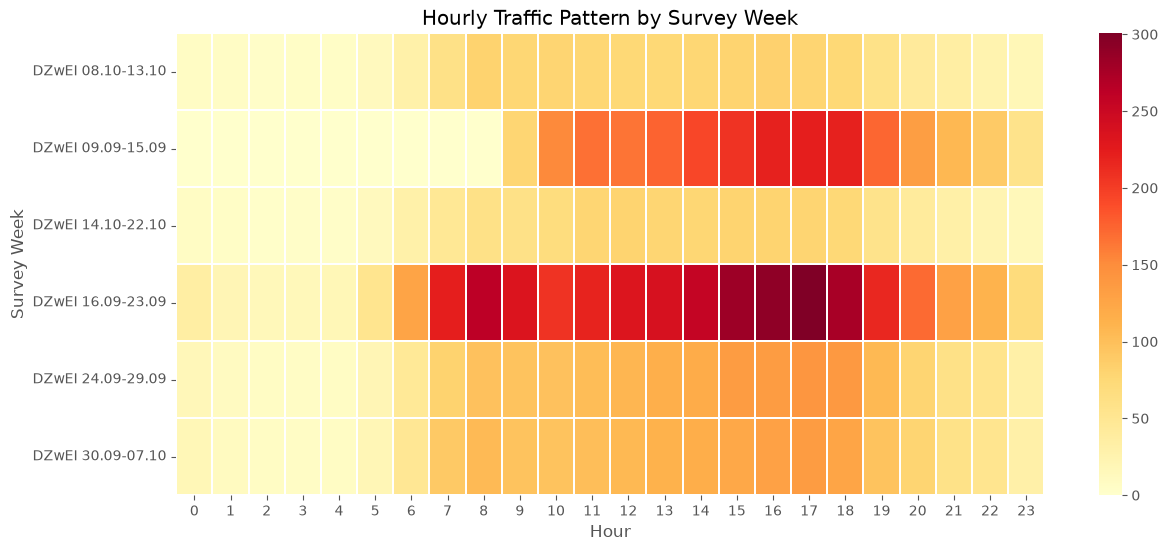

In [7]:
plt.figure(figsize=(14,6))

sns.heatmap(

    heatmap,

    cmap="YlOrRd",

    linewidths=.3

)

plt.title("Hourly Traffic Pattern by Survey Week")

plt.xlabel("Hour")

plt.ylabel("Survey Week")

plt.show()

In [8]:
weekly_vehicle = (

    df

    .groupby(

        [

            "Week",

            "Vehicle_Category"

        ]

    )

    ["Total_Traffic"]

    .mean()

    .reset_index()

)

weekly_vehicle.head()

,Week,Vehicle_Category,Total_Traffic
0,DZwEI 08.10-13.10,Bus,1.502604
1,DZwEI 08.10-13.10,Gesamt-Kfz,179.526042
2,DZwEI 08.10-13.10,Kraftrad,2.078125
3,DZwEI 08.10-13.10,LV <3.5t,174.658854
4,DZwEI 08.10-13.10,Lieferwagen,17.765625


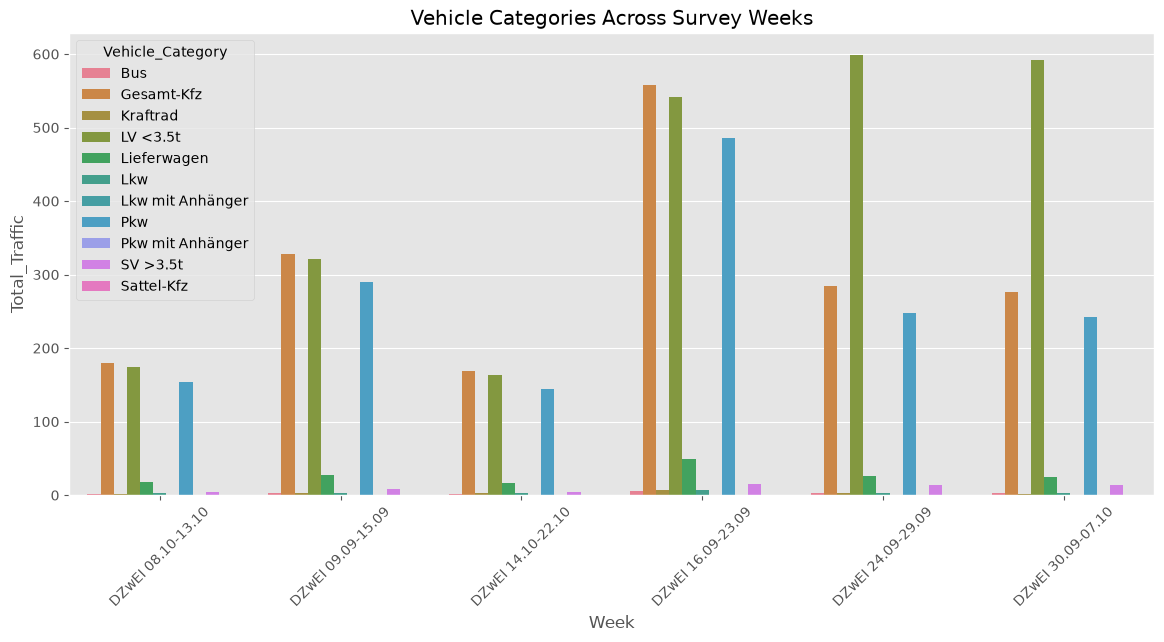

In [9]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=weekly_vehicle,

    x="Week",

    y="Total_Traffic",

    hue="Vehicle_Category"

)

plt.xticks(rotation=45)

plt.title("Vehicle Categories Across Survey Weeks")

plt.show()

In [10]:
period = (

    df

    .groupby(

        [

            "Week",

            "Peak_Period"

        ]

    )

    ["Total_Traffic"]

    .mean()

    .reset_index()

)

period

,Week,Peak_Period,Total_Traffic
0,DZwEI 08.10-13.10,Evening Peak,79.802557
1,DZwEI 08.10-13.10,Midday,76.851136
2,DZwEI 08.10-13.10,Morning Peak,62.305398
3,DZwEI 08.10-13.10,Off Peak,20.217459
4,DZwEI 09.09-15.09,Evening Peak,217.351562
5,DZwEI 09.09-15.09,Midday,170.681250
6,DZwEI 09.09-15.09,Morning Peak,19.610937
7,DZwEI 09.09-15.09,Off Peak,50.903409
8,DZwEI 14.10-22.10,Evening Peak,78.609375
9,DZwEI 14.10-22.10,Midday,76.578409


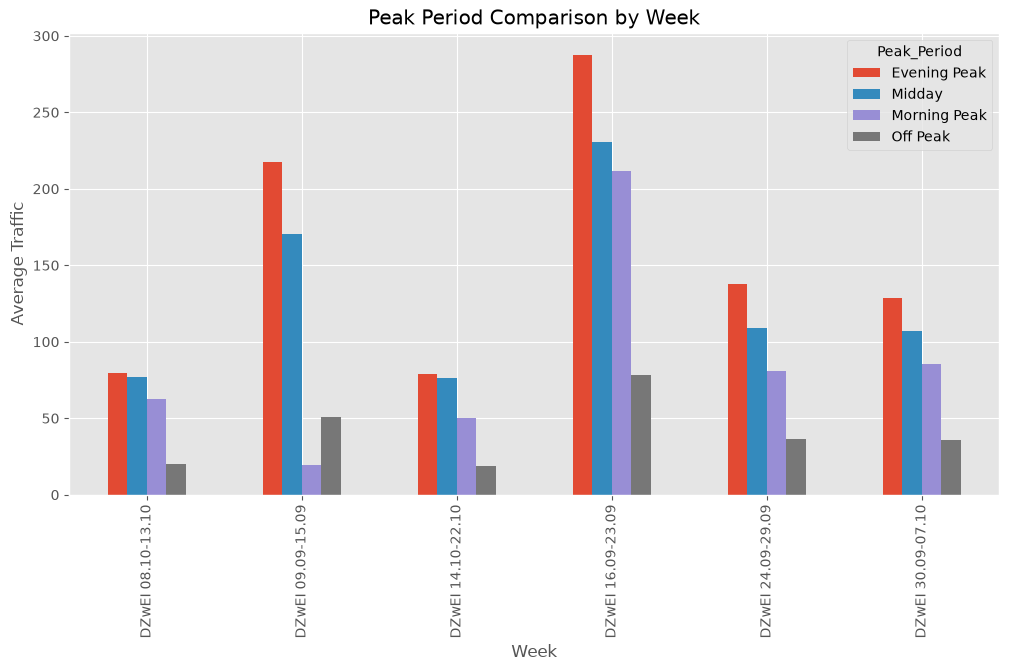

In [11]:
pivot = period.pivot(

    index="Week",

    columns="Peak_Period",

    values="Total_Traffic"

)

pivot.plot(

    kind="bar",

    figsize=(12,6)

)

plt.ylabel("Average Traffic")

plt.title("Peak Period Comparison by Week")

plt.show()

In [12]:
weekly_peak = (

    df

    .groupby(

        [

            "Week",

            "Hour"

        ]

    )

    ["Total_Traffic"]

    .mean()

    .reset_index()

)

weekly_peak = weekly_peak.loc[
    weekly_peak.groupby("Week")["Total_Traffic"].idxmax()
]

weekly_peak

,Week,Hour,Total_Traffic
16,DZwEI 08.10-13.10,16,83.352273
41,DZwEI 09.09-15.09,17,222.450000
60,DZwEI 14.10-22.10,12,80.744318
89,DZwEI 16.09-23.09,17,300.731250
113,DZwEI 24.09-29.09,17,141.131579
137,DZwEI 30.09-07.10,17,135.177632


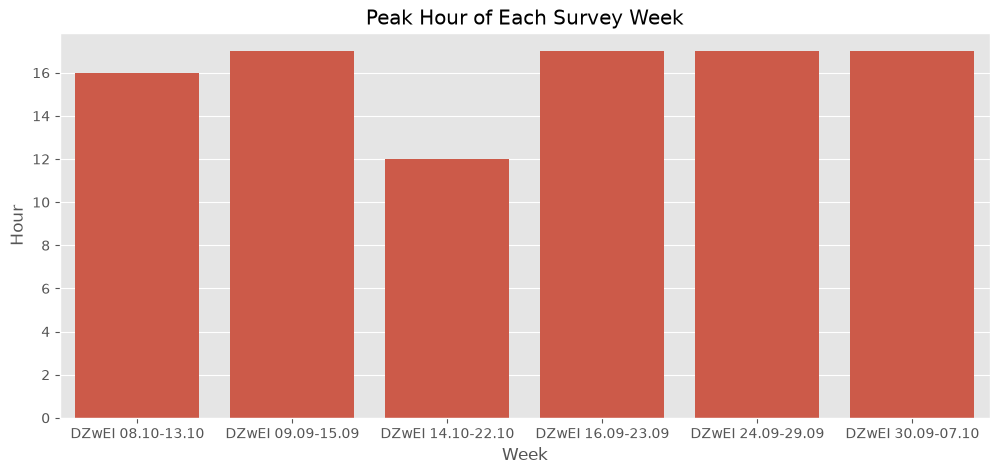

In [13]:
plt.figure(figsize=(12,5))

sns.barplot(

    data=weekly_peak,

    x="Week",

    y="Hour"

)

plt.title("Peak Hour of Each Survey Week")

plt.show()

In [14]:
ranking = (

    df

    .groupby("Week")

    ["Total_Traffic"]

    .sum()

    .sort_values(

        ascending=False

    )

)

ranking

Week
DZwEI 16.09-23.09    640959.0
DZwEI 09.09-15.09    377791.0
DZwEI 24.09-29.09    276946.0
DZwEI 30.09-07.10    270577.0
DZwEI 08.10-13.10    206814.0
DZwEI 14.10-22.10    194319.0
Name: Total_Traffic, dtype: float64

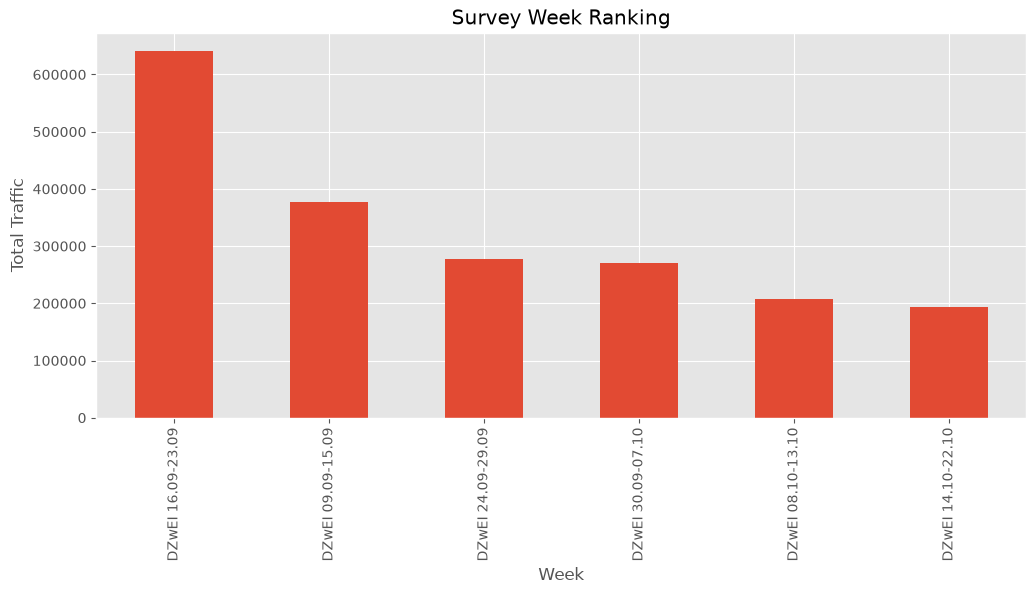

In [15]:
plt.figure(figsize=(12,5))

ranking.plot(

    kind="bar"

)

plt.ylabel("Total Traffic")

plt.title("Survey Week Ranking")

plt.show()

In [16]:
REPORT_DIR = PROJECT_DIR/"reports"

REPORT_DIR.mkdir(exist_ok=True)

weekly_peak.to_csv(

    REPORT_DIR/"weekly_peak_hours.csv",

    index=False

)

ranking.to_csv(

    REPORT_DIR/"weekly_ranking.csv"

)

print("Results Saved")

Results Saved
